In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, ConfusionMatrixDisplay)
import warnings # control warning messages because these libraries give lots of warnings which are not actually the error and only end up cluttering our notebook.

# now to ignore the warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/application_train_features.csv")
print(df.shape)
df.head()

(307511, 131)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOM,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,HAS_HOUSING_DATA,HAS_BUREAU_INQUIRY_DATA,EXT_SOURCE_1_WAS_MISSING,EXT_SOURCE_3_WAS_MISSING
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.0,False,25.920548,1.745205,2.007889,0.121978,1,1,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,False,45.931507,3.254795,4.790750,0.132217,1,1,0,1
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,False,52.180822,0.616438,2.000000,0.100000,0,1,1,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,False,52.068493,8.326027,2.316167,0.219900,0,0,1,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,False,54.608219,8.323288,4.222222,0.179963,0,1,1,1


In [7]:
X = df.drop(columns="TARGET")
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (246008, 130)
Testing set : (61503, 130)


In [8]:
numerical_features = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape :", X_test_processed.shape)

Processed Training Shape: (246008, 254)
Processed Testing Shape : (61503, 254)


In [15]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
log_reg.fit(X_train_processed, y_train)

y_pred_log = log_reg.predict(X_test_processed)
y_prob_log = log_reg.predict_proba(X_test_processed)[:, 1]

print("Logistic Regression Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_log))

Logistic Regression Results:
Accuracy : 0.6878688844446612
Precision: 0.16120738906874882
Recall   : 0.6819738167170192
F1 Score : 0.2607724594709076
ROC AUC  : 0.7503992983250364


In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

print("Random Forest Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest Results:
Accuracy : 0.9192722306228964
Precision: 0.5
Recall   : 0.0014098690835850957
F1 Score : 0.0028118096003213497
ROC AUC  : 0.7200418013291029


In [17]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train_processed, y_train)

y_pred_lgbm = lgbm_model.predict(X_test_processed)
y_prob_lgbm = lgbm_model.predict_proba(X_test_processed)[:, 1]

print("LightGBM Results:")
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lgbm))

LightGBM Results:
Accuracy : 0.7048761849015495
Precision: 0.16889312977099236
Recall   : 0.6773413897280967
F1 Score : 0.27037022148972945
ROC AUC  : 0.7594975504537279


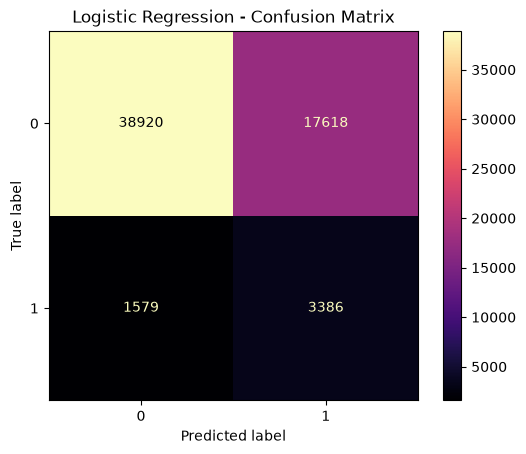

In [24]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap="magma")
disp.ax_.set_title("Logistic Regression - Confusion Matrix")
plt.show()

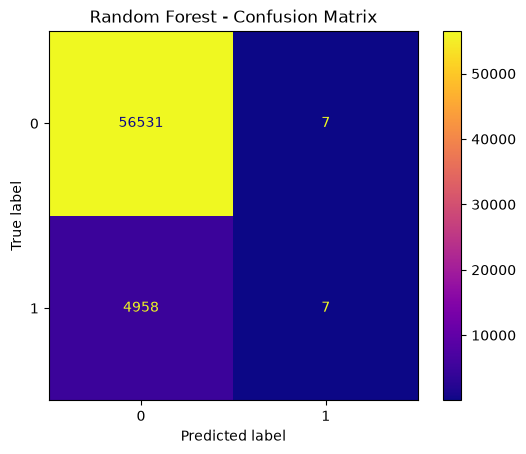

In [25]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="plasma")
disp.ax_.set_title("Random Forest - Confusion Matrix")
plt.show()

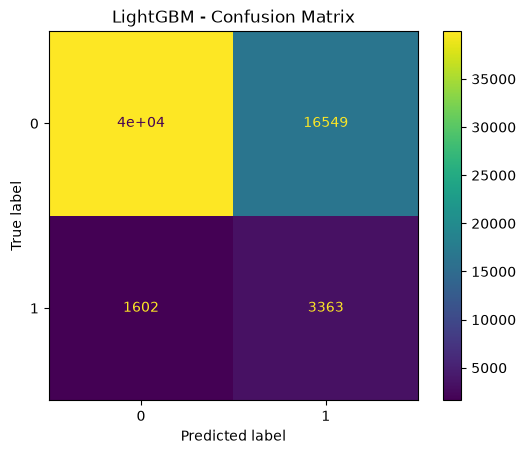

In [27]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm, cmap="viridis")
disp.ax_.set_title("LightGBM - Confusion Matrix")
plt.show()
